# Notebook 05: Normalización poblacional por distancia a comisarías

**Proyecto:** Delitos geolocalizados en CABA 2023  
**Entrada principal:** `delitos_2023_caba_enriquecido_comisarias.csv`  
**Base poblacional:** `caba_pob_barrios_2010.csv`  
**Polígonos:** `barrios.csv`

## Objetivo

El Notebook 04 mostró que la concentración territorial de delitos baja al aumentar la distancia a las sedes policiales.

Este notebook agrega una segunda normalización: población estimada.

La pregunta es:

> ¿La franja cercana a las comisarías sigue mostrando mayor concentración de delitos cuando se estima cuánta población reside en cada franja?

Para responder, se estima la población dentro de cada franja usando el porcentaje de superficie de cada barrio que cae dentro de ella.

## 1. Dependencias

Este notebook usa `geopandas`, `shapely`, `pandas` y `matplotlib`.

Si falta alguna librería, instalarla una vez en el entorno virtual:

```powershell
python -m pip install geopandas shapely pyproj matplotlib pandas
```

In [22]:
import warnings
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import wkt
from shapely.ops import unary_union
from IPython.display import display

warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

## 2. Rutas del proyecto

In [23]:
from pathlib import Path

CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name.lower() in {"notebook", "notebooks"}:
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

RAW_DATA_DIR = PROJECT_ROOT / "datasets" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "datasets" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR = REPORTS_DIR / "figures"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def find_file(candidates):
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "No se encontró ninguno de estos archivos:\n"
        + "\n".join(str(c) for c in candidates)
    )

ENRICHED_CRIME_FILE = find_file([
    PROCESSED_DATA_DIR / "delitos_2023_caba_enriquecido_comisarias.csv",
    PROJECT_ROOT / "delitos_2023_caba_enriquecido_comisarias.csv",
    Path("/mnt/data/delitos_2023_caba_enriquecido_comisarias.csv"),
])

STATIONS_FILE = find_file([
    RAW_DATA_DIR / "comisarias_policia(1).csv",
    RAW_DATA_DIR / "comisarias_policia.csv",
    PROJECT_ROOT / "comisarias_policia(1).csv",
    PROJECT_ROOT / "comisarias_policia.csv",
    Path("/mnt/data/comisarias_policia(1).csv"),
])

NEIGHBORHOODS_FILE = find_file([
    RAW_DATA_DIR / "barrios.csv",
    PROJECT_ROOT / "barrios.csv",
    Path("/mnt/data/barrios.csv"),
])

print("Archivo de delitos enriquecido:", ENRICHED_CRIME_FILE)
print("Archivo de sedes policiales:", STATIONS_FILE)
print("Archivo de barrios:", NEIGHBORHOODS_FILE)

# caba_pob_barrios_2022_estimado.csv para utilizar poblacion barrial
# estimada por dataset de comunas base 2022
POPULATION_FILE = find_file([
    RAW_DATA_DIR / "caba_pob_barrios_2010.csv",
    PROJECT_ROOT / "caba_pob_barrios_2010.csv",
    Path("/mnt/data/caba_pob_barrios_2010.csv"),
])

print("Archivo de población por barrio:", POPULATION_FILE)

Archivo de delitos enriquecido: C:\Users\nikko\CienciaDatosDelitosTPO\datasets\processed\delitos_2023_caba_enriquecido_comisarias.csv
Archivo de sedes policiales: C:\Users\nikko\CienciaDatosDelitosTPO\datasets\raw\comisarias_policia.csv
Archivo de barrios: C:\Users\nikko\CienciaDatosDelitosTPO\datasets\raw\barrios.csv
Archivo de población por barrio: C:\Users\nikko\CienciaDatosDelitosTPO\datasets\raw\caba_pob_barrios_2010.csv


## 3. Funciones auxiliares

In [24]:
def normalize_name(value):
    """
    Normaliza nombres de barrios para que los archivos puedan unirse.

    Caso puntual:
    - En la base de población figura "BOCA".
    - En el polígono barrial figura "La Boca".
    """
    value = str(value).upper().strip()
    value = "".join(
        character
        for character in unicodedata.normalize("NFKD", value)
        if not unicodedata.combining(character)
    )

    replacements = {
        "LA BOCA": "BOCA",
    }

    return replacements.get(value, value)


def prepare_distance_zones(neighborhoods_file, stations_file):
    barrios = pd.read_csv(neighborhoods_file)
    sedes = pd.read_csv(stations_file)

    barrios["geometry"] = barrios["geometry"].apply(wkt.loads)
    sedes["geometry"] = sedes["geometry"].apply(wkt.loads)

    barrios_gdf = gpd.GeoDataFrame(
        barrios,
        geometry="geometry",
        crs="EPSG:4326",
    )

    sedes_gdf = gpd.GeoDataFrame(
        sedes,
        geometry="geometry",
        crs="EPSG:4326",
    )

    metric_crs = barrios_gdf.estimate_utm_crs()

    barrios_m = barrios_gdf.to_crs(metric_crs)
    sedes_m = sedes_gdf.to_crs(metric_crs)

    # Se eliminan duplicados físicos: hay 75 registros administrativos,
    # pero 63 sedes físicas únicas.
    sedes_m["x_coord"] = sedes_m.geometry.x.round(3)
    sedes_m["y_coord"] = sedes_m.geometry.y.round(3)
    sedes_unicas_m = sedes_m.drop_duplicates(
        subset=["x_coord", "y_coord"],
    ).copy()

    caba_geom = unary_union(barrios_m.geometry)

    band_specs = [
        {
            "orden": 1,
            "franja_distancia_comisaria": "ENTORNO INMEDIATO (0-500 m)",
            "desde_m": 0,
            "hasta_m": 500,
        },
        {
            "orden": 2,
            "franja_distancia_comisaria": "CERCANA (501-900 m)",
            "desde_m": 501,
            "hasta_m": 900,
        },
        {
            "orden": 3,
            "franja_distancia_comisaria": "INTERMEDIA (901-1350 m)",
            "desde_m": 901,
            "hasta_m": 1350,
        },
        {
            "orden": 4,
            "franja_distancia_comisaria": "ALEJADA (MAS DE 1350 m)",
            "desde_m": 1351,
            "hasta_m": None,
        },
    ]

    cumulative_radii = [500, 900, 1350]
    previous = None
    zone_geometries = []

    for radius in cumulative_radii:
        buffer_union = unary_union(sedes_unicas_m.buffer(radius))
        clipped = caba_geom.intersection(buffer_union)

        if previous is None:
            ring = clipped
        else:
            ring = clipped.difference(previous)

        zone_geometries.append(ring)
        previous = clipped

    zone_geometries.append(caba_geom.difference(previous))

    zonas = gpd.GeoDataFrame(
        band_specs,
        geometry=zone_geometries,
        crs=metric_crs,
    )

    zonas["superficie_km2"] = zonas.geometry.area / 1_000_000

    return zonas, barrios_m, sedes_unicas_m, metric_crs

## 4. Carga de datos

In [25]:
delitos = pd.read_csv(
    ENRICHED_CRIME_FILE,
    low_memory=False,
)

poblacion = pd.read_csv(
    POPULATION_FILE,
)

required_crime_columns = {
    "franja_distancia_comisaria",
}

required_population_columns = {
    "BARRIO",
    "POBLACION",
}

missing_crime_columns = sorted(required_crime_columns - set(delitos.columns))
missing_population_columns = sorted(required_population_columns - set(poblacion.columns))

if missing_crime_columns:
    raise ValueError(f"Faltan columnas en delitos: {missing_crime_columns}")

if missing_population_columns:
    raise ValueError(f"Faltan columnas en población: {missing_population_columns}")

print("Delitos cargados:", len(delitos))
print("Barrios en base poblacional:", len(poblacion))
print("Población total base 2010:", poblacion["POBLACION"].sum())

display(poblacion.head())

Delitos cargados: 152739
Barrios en base poblacional: 48
Población total base 2010: 2890151


,BARRIO,POBLACION
0,AGRONOMIA,13912
1,ALMAGRO,131699
2,BALVANERA,138926
3,BARRACAS,89452
4,BELGRANO,126267


## 5. Reconstrucción de franjas territoriales

Se reutiliza la misma lógica del Notebook 04 para construir zonas de distancia:

- 0-500 m;
- 501-900 m;
- 901-1350 m;
- más de 1350 m.

In [26]:
zonas_distancia, barrios_m, sedes_unicas_m, metric_crs = prepare_distance_zones(
    NEIGHBORHOODS_FILE,
    STATIONS_FILE,
)

print("CRS métrico usado:", metric_crs)
print("Superficie total de CABA reconstruida:", zonas_distancia["superficie_km2"].sum().round(2), "km²")

display(zonas_distancia[[
    "orden",
    "franja_distancia_comisaria",
    "superficie_km2",
]])

CRS métrico usado: EPSG:32721
Superficie total de CABA reconstruida: 203.91 km²


,orden,franja_distancia_comisaria,superficie_km2
0,1,ENTORNO INMEDIATO (0-500 m),43.05
1,2,CERCANA (501-900 m),63.86
2,3,INTERMEDIA (901-1350 m),53.11
3,4,ALEJADA (MAS DE 1350 m),43.88


## 6. Unión de barrios con población

Se une la base de población barrial con los polígonos.

La diferencia de nombre entre `BOCA` y `La Boca` se corrige antes del cruce.

In [27]:
poblacion = poblacion.copy()
poblacion["barrio_norm"] = poblacion["BARRIO"].apply(normalize_name)

barrios_m = barrios_m.copy()
barrios_m["barrio_norm"] = barrios_m["nombre"].apply(normalize_name)
barrios_m["superficie_barrio_km2"] = barrios_m.geometry.area / 1_000_000

barrios_poblacion = barrios_m.merge(
    poblacion[["barrio_norm", "POBLACION"]],
    on="barrio_norm",
    how="left",
)

barrios_sin_poblacion = barrios_poblacion[
    barrios_poblacion["POBLACION"].isna()
][["nombre", "barrio_norm"]]

if len(barrios_sin_poblacion) > 0:
    display(barrios_sin_poblacion)
    raise ValueError("Hay barrios sin población asignada.")

print("Barrios con población asignada:", len(barrios_poblacion))
print("Población total asignada:", barrios_poblacion["POBLACION"].sum())

Barrios con población asignada: 48
Población total asignada: 2890151


## 7. Estimación de población por franja

La población se distribuye proporcionalmente según la superficie de cada barrio que cae dentro de cada franja.

```text
población estimada en franja
=
población del barrio
×
área del barrio dentro de la franja
/
área total del barrio
```

Es una aproximación: supone población distribuida de manera uniforme dentro de cada barrio.

In [28]:
intersecciones = gpd.overlay(
    barrios_poblacion[[
        "nombre",
        "comuna",
        "POBLACION",
        "superficie_barrio_km2",
        "geometry",
    ]],
    zonas_distancia[[
        "orden",
        "franja_distancia_comisaria",
        "geometry",
    ]],
    how="intersection",
)

intersecciones["superficie_interseccion_km2"] = (
    intersecciones.geometry.area
    / 1_000_000
)

intersecciones["factor_area_barrio"] = (
    intersecciones["superficie_interseccion_km2"]
    / intersecciones["superficie_barrio_km2"]
)

intersecciones["poblacion_estimada"] = (
    intersecciones["POBLACION"]
    * intersecciones["factor_area_barrio"]
)

control_poblacion = intersecciones["poblacion_estimada"].sum()

print("Población original:", poblacion["POBLACION"].sum())
print("Población estimada distribuida:", round(control_poblacion, 2))

display(intersecciones[[
    "nombre",
    "comuna",
    "franja_distancia_comisaria",
    "superficie_interseccion_km2",
    "factor_area_barrio",
    "poblacion_estimada",
]].head())

Población original: 2890151
Población estimada distribuida: 2890151.0


,nombre,comuna,franja_distancia_comisaria,superficie_interseccion_km2,factor_area_barrio,poblacion_estimada
0,Agronomia,15,ENTORNO INMEDIATO (0-500 m),0.24,0.11,"1,589.90"
1,Agronomia,15,CERCANA (501-900 m),0.62,0.29,"4,037.48"
2,Agronomia,15,INTERMEDIA (901-1350 m),0.56,0.26,"3,640.29"
3,Agronomia,15,ALEJADA (MAS DE 1350 m),0.71,0.33,"4,644.32"
4,Almagro,5,ENTORNO INMEDIATO (0-500 m),0.70,0.17,"22,659.41"


## 8. Delitos cada 10.000 habitantes estimados

In [29]:
orden_franjas = zonas_distancia.sort_values("orden")["franja_distancia_comisaria"].tolist()

conteo_delitos = (
    delitos
    .groupby("franja_distancia_comisaria")
    .size()
    .reindex(orden_franjas)
    .rename("cantidad_delitos")
    .reset_index()
)

reporte_poblacional = (
    intersecciones
    .groupby(["orden", "franja_distancia_comisaria"], as_index=False)
    .agg(
        superficie_km2=("superficie_interseccion_km2", "sum"),
        poblacion_estimada=("poblacion_estimada", "sum"),
    )
    .merge(
        conteo_delitos,
        on="franja_distancia_comisaria",
        how="left",
    )
    .sort_values("orden")
)

reporte_poblacional["cantidad_delitos"] = reporte_poblacional["cantidad_delitos"].fillna(0).astype(int)
reporte_poblacional["densidad_hab_km2"] = (
    reporte_poblacional["poblacion_estimada"]
    / reporte_poblacional["superficie_km2"]
)
reporte_poblacional["delitos_por_km2"] = (
    reporte_poblacional["cantidad_delitos"]
    / reporte_poblacional["superficie_km2"]
)
reporte_poblacional["delitos_cada_10k_hab"] = (
    reporte_poblacional["cantidad_delitos"]
    / reporte_poblacional["poblacion_estimada"]
    * 10_000
)
reporte_poblacional["indice_10k_vs_0_500"] = (
    reporte_poblacional["delitos_cada_10k_hab"]
    / reporte_poblacional.loc[
        reporte_poblacional["orden"] == 1,
        "delitos_cada_10k_hab",
    ].iloc[0]
)

display(reporte_poblacional)

,orden,franja_distancia_comisaria,superficie_km2,poblacion_estimada,cantidad_delitos,densidad_hab_km2,delitos_por_km2,delitos_cada_10k_hab,indice_10k_vs_0_500
0,1,ENTORNO INMEDIATO (0-500 m),43.05,"694,804.60",47871,"16,140.42","1,112.05",688.99,1.00
1,2,CERCANA (501-900 m),63.86,"966,088.31",55074,"15,127.12",862.36,570.07,0.83
2,3,INTERMEDIA (901-1350 m),53.11,"706,592.60",31953,"13,303.27",601.59,452.21,0.66
3,4,ALEJADA (MAS DE 1350 m),43.88,"522,665.48",17841,"11,911.25",406.59,341.35,0.50


## 9. Visualización: población y tasa de delitos

Se comparan dos medidas:

1. densidad poblacional estimada;
2. delitos cada 10.000 habitantes estimados.

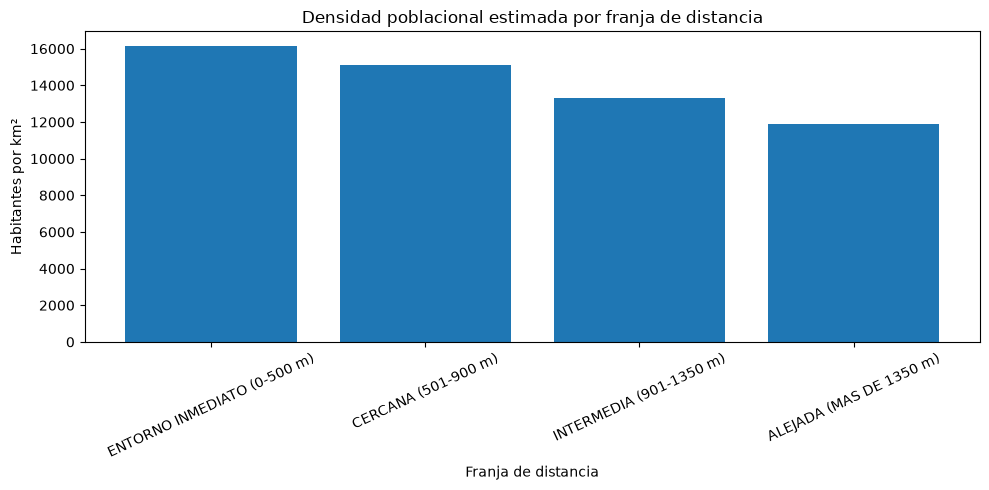

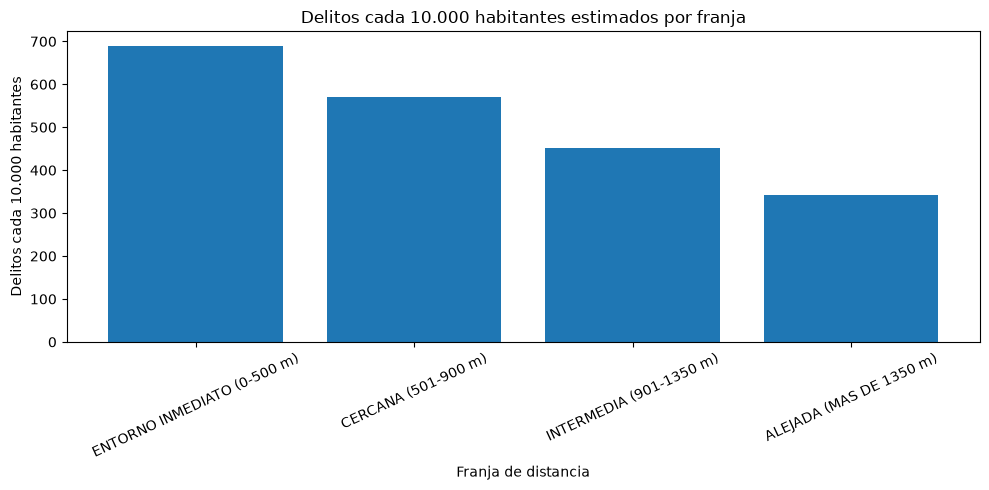

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    reporte_poblacional["franja_distancia_comisaria"],
    reporte_poblacional["densidad_hab_km2"],
)
ax.set_title("Densidad poblacional estimada por franja de distancia")
ax.set_xlabel("Franja de distancia")
ax.set_ylabel("Habitantes por km²")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
fig.savefig(
    FIGURES_DIR / "densidad_poblacional_estimada_por_franja_distancia.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    reporte_poblacional["franja_distancia_comisaria"],
    reporte_poblacional["delitos_cada_10k_hab"],
)
ax.set_title("Delitos cada 10.000 habitantes estimados por franja")
ax.set_xlabel("Franja de distancia")
ax.set_ylabel("Delitos cada 10.000 habitantes")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
fig.savefig(
    FIGURES_DIR / "delitos_cada_10k_habitantes_por_franja_distancia.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

## 10. Guardado de reportes

Se guardan dos tablas:

- reporte agregado por franja;
- detalle barrio-franja usado para estimar población.

In [31]:
population_report_file = TABLES_DIR / "reporte_normalizacion_poblacional.csv"
population_detail_file = TABLES_DIR / "detalle_poblacion_estimada_barrio_franja.csv"

reporte_poblacional.to_csv(
    population_report_file,
    index=False,
    encoding="utf-8-sig",
)

intersecciones[[
    "nombre",
    "comuna",
    "franja_distancia_comisaria",
    "superficie_interseccion_km2",
    "factor_area_barrio",
    "POBLACION",
    "poblacion_estimada",
]].to_csv(
    population_detail_file,
    index=False,
    encoding="utf-8-sig",
)

print("Reporte poblacional guardado en:", population_report_file)
print("Detalle barrio-franja guardado en:", population_detail_file)

Reporte poblacional guardado en: C:\Users\nikko\CienciaDatosDelitosTPO\reports\tables\reporte_normalizacion_poblacional.csv
Detalle barrio-franja guardado en: C:\Users\nikko\CienciaDatosDelitosTPO\reports\tables\detalle_poblacion_estimada_barrio_franja.csv


## 11. Conclusión del notebook

Al incorporar población estimada, la lectura vuelve a cambiar respecto de la cantidad absoluta.

La franja 0-500 m:

- no es la que más delitos acumula en valores absolutos;
- pero sí presenta la mayor tasa de delitos cada 10.000 habitantes estimados;
- y la tasa baja progresivamente al alejarse de las sedes policiales.

**Conclusión:** no se observa evidencia de un efecto disuasorio asociado con la cercanía física a una sede policial. La menor cantidad absoluta en el entorno inmediato se explica por menor superficie y menor población total. Al normalizar, la concentración relativa es mayor cerca de las sedes.

## Limitaciones

- La población usada corresponde a 2010, mientras que los delitos son de 2023. Pero se replico con poblacion 2022 estimada con datos ciertos por comuna con identicos resultados.
- La estimación supone distribución uniforme de la población dentro de cada barrio.
- La población residencial no mide población flotante, actividad comercial, turismo ni tránsito peatonal.
- La distancia a una sede policial no mide patrullaje efectivo, cámaras, operativos ni cantidad de personal.